In [182]:
import sys
from graphviz import Digraph
from collections import deque

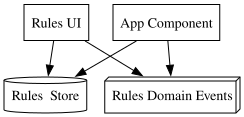

In [185]:
dot = Digraph(format='svg')

dot.node(name = 'rulesdb', label="Rules  Store", shape='cylinder')
dot.node(name = 'ui', label="Rules UI", shape='record')
dot.node(name = 'eventstore', label="Rules Domain Events", shape='box3d')
dot.node(name = 'app', label="App Component", shape='record')

dot.edge('ui', 'rulesdb')
dot.edge('ui', 'eventstore')
dot.edge('app', 'eventstore')
dot.edge('app', 'rulesdb')
dot

### 1. An aggregate with attribues that are defined using the ubiquitous language 

In [186]:
class Customer:
    def __init__(self, name, age, credit_risk, income, spend):
        self.name = name
        self.age = age
        self.credit_risk = credit_risk
        self.income = income
        self.spend = spend

    def __repr__(self):
        return f"(name = {self.name}, age = {self.age}, credit_risk = {self.credit_risk}"

good_customer = Customer('Good Customer', 30, 0.1, 1000, 100)
risky_customer = Customer('Risky Customer', 34, 0.9, 100, 1000)
good_customer

(name = Good Customer, age = 30, credit_risk = 0.1

### 2. Externally configured rules that uses the ubiquitous language (Configuration over Coding principle). These rules will be maintained in a repository (key-value store)
#### There will be an user interface (wizard) using which these booolean rules will be configured. The ubiquitous terms will be used as operands on the LHS or RHS. The UI will allow the user to select the Aggregate and list the Attributes to construct these rules. The operand will be saved in Aggregrate->Attribute format so that the execution engine can parse it using this pattern.

In [187]:
rule_set = { "high_risk" : '(customer->spend greater than customer->income ) or (customer->age greater than 25 and customer->credit_risk greater than 0.5)',
             "low_risk" : 'customer->age greater than 25 and customer->credit_risk less than or equal to 0.5'}

### 3. Compile the rules
#### All the rules will be compiled when the applcation starts. There will also be hot deployment of new rules and changes to the existing rules. Such changes will be communicated to the application in an 'event driven' fashion.

In [188]:
def match_paranthesis(rule):
    stack = deque()
    for i, char in enumerate(rule):
        if(char == '('):
            stack.append(char)
        if(char == ')'):
            if(len(stack) == 0):
                return False
            else:
                stack.pop()
    if (len(stack) > 0):
        return False
    return True
        
def english_to_python(rule):
    _operatorsToPython = {'greater than or equal to' : ' >= ',
        'less than or equal to' : ' <= ',
        'greater than' : " > ",
        'less than' : " < ",
        'equal to' : ' == ',
        'not equal to' : ' != ',
        'AND' : ' && ',
        'OR' :  ' || '}
    if(match_paranthesis(rule) == False):
        raise Exception("Paranthesis mismatch in :" + rule)
    for operator in _operatorsToPython:
        rule = rule.replace(operator, _operatorsToPython[operator])
    #replace the c++ pointer like delimiter into python friendly
    rule = rule.replace("->", "__")
    rule = 'result = ' + rule
    return rule
 
def compile_rules(rule_set):
    compiled_rules = {}
    try:
        for rule in rule_set:
            python_rule = english_to_python(rule_set[rule])
            print(python_rule)
            compiled_rule = compile(python_rule, '<string>', 'exec')
            compiled_rules[rule] = compiled_rule
    except:
         print(sys.exec_info('traceback'))
         exit()
    return compiled_rules

In [ ]:
match_paranthesis("((((abc > xy))))")

In [189]:
compiled_rules = compile_rules(rule_set)
for crule in compiled_rules:
    print(compiled_rules[crule].co_names)

result = (customer__spend  >  customer__income ) or (customer__age  >  25 and customer__credit_risk  >  0.5)
result = customer__age  >  25 and customer__credit_risk  <=  0.5
('customer__spend', 'customer__income', 'customer__age', 'customer__credit_risk', 'result')
('customer__age', 'customer__credit_risk', 'result')


### 4. Rule Evaluation
#### a/ Bind the variables used in the rules with actual values from the Aggregate objects. b/ Execute the compiled rule

In [190]:
def evaluate(rule, aggregate_map):
    bindings = {}
    compiled_rule = compiled_rules[rule]
    for var in compiled_rule.co_names:
        if var != 'result':
            splits = var.split("__") #splits[0] is the aggreate and [1] is the attribute
            bindings[var] = getattr(aggregate_map[splits[0]], splits[1])
    exec(compiled_rule, globals(), bindings)
    return bindings['result']

In [191]:
print(evaluate('low_risk', {'customer' : good_customer}))
print(evaluate('high_risk', {'customer' : good_customer}))

True
False
